## Preparação e procedimento com relação aos dados:
O primeiro passo do projeto consiste em carregar, verificar e entender os dados geológicos das três regiões exploradas. Cada arquivo contém medicções de poços  de petróleo e o volume de reservas. O propósito é garantir que os dados estejam limpos, consistentes e prontos para modelagem.

Os três arquivos CSV foram carregados e verificados quanto a estrutura e o tipo de dados:
* Confirmada a presença das colunas id, f0, f1, f2 e product;
* Ajustado id para o tipo string;
* Conferido tipos numéricos para as variáveis f0, f1, f2 e product.
* Checagem de dados ausentes e duplicados: <Nenhum valor nulo ou duplicado foi encontrado>.
* Analise estatísticas descritivas:
* Média, desvio padrão, mínimos e máximos, para entender escala e dispersão.
  
Calculado correlações com o alvo (product): Isso ajuda a perceber o quanto cada variável pode contribuir para prever o volume de petróleo.

In [1]:
# Passo 1. Baixar e analisar os dados 
import pandas as pd
import numpy as np
from pathlib import Path

EXPECTED_COLS = ['id', 'f0', 'f1', 'f2', 'product']

def quick_report(df, name=""):
    print(f"\n=== {name} ===")
    print("shape:", df.shape)
    print("\nTipos de dados:")
    print(df.dtypes)
    print("\nNulos por coluna:")
    print(df.isna().sum())
    print("\nDuplicatas (linhas idênticas):", df.duplicated().sum())
    print("\nEstatísticas descritivas (f0,f1,f2,product):")
    print(df[['f0','f1','f2','product']].describe().T)
    print("\nPrimeiras linhas:")
    print(df.head())

def load_and_prepare(path, name=""):
    # 1. Carregar
    df = pd.read_csv(path)
    
    # 2. Checar colunas esperadas
    missing = set(EXPECTED_COLS) - set(df.columns)
    if missing:
        raise ValueError(f"{name}: faltam colunas: {missing}")
        
    # 3. tipos: id como string
    df['id'] = df['id'].astype(str)
    
    # 4. Remover duplicatas exatas, se houver
    dup_count = df.duplicated().sum()
    if dup_count:
        df = df.drop_duplicates().reset_index(drop=True)
        
    # 5. Quick report
    quick_report(df, name)
    return df
    
     # 6) Mostrar primeiras linhas para inspeção
    display_dataframe_to_user(f"{name} — primeiras linhas", df.head(10))

base = Path(".")
paths = {
    "Região 0": base / "geo_data_0.csv",
    "Região 1": base / "geo_data_1.csv",
    "Região 2": base / "geo_data_2.csv",
}

dfs = {}
for name, p in paths.items():
    if not p.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {p}")
    dfs[name] = load_and_prepare(p, name=name)

    # Correlações com o alvo e resumo do alvo
def corr_with_target(df, name=""):
    print(f"\nCorrelação com product — {name}")
    print(df[['f0','f1','f2','product']].corr()['product'].sort_values(ascending=False))
    
def target_summary(df, name=""):
    y = df['product']
    print(f"\nAlvo (product) — {name}")
    print("média:", float(y.mean()))
    print("mediana:", float(y.median()))
    p10, p90 = np.percentile(y, [10, 90])
    print("p10/p90:", float(p10), float(p90))
    print("mín/máx:", float(y.min()), float(y.max()))

for name, df in dfs.items():
    corr_with_target(df, name)
    target_summary(df, name)

print("\nPasso 1 concluído: dados carregados e checados.")



,=== Região 0 ===
,shape: (100000, 5)
,
,Tipos de dados:
,id          object
,f0         float64
,f1         float64
,f2         float64
,product    float64
,dtype: object
,
,Nulos por coluna:
,id         0
,f0         0
,f1         0
,f2         0
,product    0
,dtype: int64
,
,Duplicatas (linhas idênticas): 0
,
,Estatísticas descritivas (f0,f1,f2,product):
,            count       mean        std        min        25%        50%  \
,f0       100000.0   0.500419   0.871832  -1.408605  -0.072580   0.502360   
,f1       100000.0   0.250143   0.504433  -0.848218  -0.200881   0.250252   
,f2       100000.0   2.502647   3.248248 -12.088328   0.287748   2.515969   
,product  100000.0  92.500000  44.288691   0.000000  56.497507  91.849972   
,
,                75%         max  
,f0         1.073581    2.362331  
,f1         0.700646    1.343769  
,f2         4.715088   16.003790  
,product  128.564089  185.364347  
,
,Primeiras linhas:
,      id        f0        f1        f2     product
,0 

## Conclusão
As três regiões têm dados bem estruturados e prontos para análise. 
A região 1 apresenta o comportamento mais linear entre as variáveis e o volume de reservas — isso significa que o modelo de regressão linear provavelmente terá melhor precisão nessa área.
As regiões 0 e 2 possuem médias de produção mais altas, mas com maior dispersão e ruído, o que pode dificultar a previsão exata do volume de reservas.

* Região 1 tende a ser a mais previsível (dados mais “limpos”).
* Região 2 tende a ser a mais produtiva, mas com maior variabilidade.
O próximo passo avaliará qual delas gera o melhor equilíbrio entre previsibilidade e volume, medindo o desempenho da regressão linear.

## 2. Treinar e testar o modelo para cada região
Construir e avaliar um modelo de Regressão Linear para estimar o volume de reservas (product) em cada uma das três regiões.
O modelo será treinado com 75% dos dados e validado com os 25% restantes, e avaliaremos seu desempenho com o RMSE (Root Mean Squared Error) e a média das predições.
O objetivo é verificar o quão bem o modelo consegue prever o volume de reservas (product) com base nas variáveis f0, f1 e f2.

*Procedimento executado:*

Divisão dos dados (75 / 25)
* 75 % das observações foram usadas para treinar o modelo;
* 25 % foram reservadas para validação.
Essa separação garante que o modelo seja avaliado em dados que nunca “viu” durante o treinamento.

*Treinamento do modelo*

Foi utilizada a classe LinearRegression() da biblioteca scikit-learn.
O modelo aprende os coeficientes que melhor ajustam a relação linear entre as features e o alvo product.

*Predição e avaliação:*
As predições foram feitas sobre o conjunto de validação.

*Foram calculados:*
* Média prevista de reservas → volume médio estimado de petróleo (em milhares de barris).
* RMSE – Root Mean Squared Error → mede o erro médio das previsões; quanto menor, melhor.

*Função automatizada:*
Todo o processo (2.1 – 2.5) foi encapsulado na função train_and_evaluate_region().
A função foi executada para os três datasets (geo_data_0, geo_data_1, geo_data_2).

In [2]:
# Passo 2. Treinar e testar o modelo por região 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Variável global: random_state para garantir reprodutibilidade
RANDOM_STATE = 42

# Função para treinar, prever e avaliar um modelo em uma região
def train_and_evaluate_region(df, region_name):
    print(f"\n=== {region_name} ===")
    
    # 1 - Dividir em treino (75%) e validação (25%)
    features = df[['f0', 'f1', 'f2']]
    target = df['product']
    
    X_train, X_valid, y_train, y_valid = train_test_split(
        features, target, test_size=0.25, random_state=RANDOM_STATE
    )
    
    # 2 - Treinar o modelo
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # 3 - Fazer predições no conjunto de validação
    predictions = model.predict(X_valid)
    
    # 4 - Calcular métricas
    rmse = mean_squared_error(y_valid, predictions, squared=False)
    mean_pred = np.mean(predictions)
    
    print(f"Média prevista das reservas: {mean_pred:.2f}")
    print(f"RMSE (erro médio quadrático): {rmse:.2f}")
    
    # 5 - Retornar resultados para uso posterior
    return {
        'region': region_name,
        'model': model,
        'y_valid': y_valid.reset_index(drop=True),
        'y_pred': pd.Series(predictions).reset_index(drop=True),
        'rmse': rmse,
        'mean_pred': mean_pred
    }

   # 6 - Executar para as três regiões 
results = []
results.append(train_and_evaluate_region(dfs['Região 0'], 'Região 0'))
results.append(train_and_evaluate_region(dfs['Região 1'], 'Região 1'))
results.append(train_and_evaluate_region(dfs['Região 2'], 'Região 2'))



,=== Região 0 ===
,Média prevista das reservas: 92.40
,RMSE (erro médio quadrático): 37.76
,
,=== Região 1 ===
,Média prevista das reservas: 68.71
,RMSE (erro médio quadrático): 0.89
,
,=== Região 2 ===
,Média prevista das reservas: 94.77
,RMSE (erro médio quadrático): 40.15


## Interpretação e Conclusão
A Região 1 apresenta o menor RMSE, confirmando o que foi observado no Passo 1:
as variáveis dessa região possuem correlação linear quase perfeita com o volume de reservas.
As Regiões 0 e 2 possuem maior dispersão e, portanto, o modelo linear não consegue capturar toda a variação dos dados.

As médias previstas estão próximas das médias reais, o que mostra que o modelo não tende a superestimar nem subestimar o volume médio de produção.

Conclui-se:
Os modelos de regressão linear foram treinados e avaliados com sucesso.
A análise confirma que:

*Região 1* tem o melhor desempenho preditivo (menor RMSE);

*Regiões 0 e 2* mostram maior erro de previsão, indicando variabilidade natural dos dados;

Todos os modelos estão agora prontos para a etapa seguinte, onde será calculado o lucro esperado de cada região considerando o investimento e a produção prevista.

## 3. Cálculo de lucro
Antes de calcular o lucro potencial de cada região, precisamos definir:

1. Constantes econômicas do projeto (preço, orçamento, número de poços, etc.);

2. Volume mínimo necessário por poço para evitar prejuízo (break-even point);

3. Comparar o volume médio real de cada região com esse limite.

In [3]:
# Passo 3. Preparação para o cálculo de lucro

PRICE = 4500               # receita por unidade (mil barris)
BUDGET = 100_000_000       # orçamento total
N_WELLS = 200              # número de poços desenvolvidos
BATCH = 500                # número de poços analisados por região
BREAK_EVEN_UNITS = BUDGET / (N_WELLS * PRICE)

print(f"Ponto de equilíbrio (break-even): {BREAK_EVEN_UNITS:.2f} mil barris por poço")

# Comparar com a média real de cada região
for name, df in dfs.items():
    mean_prod = df['product'].mean()
    print(f"{name}: média real de {mean_prod:.2f} mil barris")

print("\nConclusão: regiões com média bem acima de 111.11 mil barris têm menor risco de prejuízo.")


Ponto de equilíbrio (break-even): 111.11 mil barris por poço
,Região 0: média real de 92.50 mil barris
,Região 1: média real de 68.83 mil barris
,Região 2: média real de 95.00 mil barris
,
,Conclusão: regiões com média bem acima de 111.11 mil barris têm menor risco de prejuízo.


## Conclusão
Definido os parâmetros financeiros do projeto e o ponto de equilíbrio necessário para cobrir o investimento.
Cada poço deve produzir pelo menos 111,11 mil barris para evitar prejuízo.
As médias observadas nas três regiões estão abaixo desse valor, o que indica que o sucesso depende da escolha dos poços mais produtivos.



## 4. Lucro em conjunto de poços de petróleo e predições do modelo

Determinar o lucro total estimado para cada uma das três regiões, com base:

* nas predições do modelo (volume de reservas), e no valor real de produção (product) correspondente.

A ideia é selecionar os 200 poços com maior previsão de reservas em cada região e calcular o lucro que eles gerariam, considerando o custo fixo de $100 milhões.


In [4]:
# Passo 4. Cálculo do lucro potencial 

PRICE = 4500        # dólares por unidade (mil barris)
BUDGET = 100_000_000
TOP_N = 200         # número de poços escolhidos

def calculate_profit(y_true, y_pred, price=PRICE, budget=BUDGET, top_n=TOP_N):
    """Calcula o lucro com base nos top_n poços com maiores predições."""
    
    # índices dos 200 poços com maiores valores previstos
    top_idx = np.argsort(y_pred)[-top_n:]
    
    # soma o volume real de petróleo nesses poços
    total_volume = y_true.iloc[top_idx].sum()
    
    # receita total
    revenue = total_volume * price
    
    # lucro final
    profit = revenue - budget
    return profit

# Calcular lucro para cada região
for res in results:
    profit = calculate_profit(res['y_valid'], res['y_pred'])
    print(f"{res['region']}: Lucro estimado = ${profit:,.2f}")


Região 0: Lucro estimado = $33,591,411.14
,Região 1: Lucro estimado = $24,150,866.97
,Região 2: Lucro estimado = $25,985,717.59


## Conclusão

O cálculo de lucro foi realizado selecionando os 200 poços com maiores valores previstos de cada região.
O lucro de cada região depende tanto da qualidade das previsões quanto do volume real de reservas nesses poços.
Após avaliar o desempenho dos modelos e o lucro estimado para cada região:

* **Região 0** apresentou o maior lucro estimado ($33,6 milhões), porém com um erro preditivo elevado (RMSE ≈ 37,76). Isso significaque, embora tenha potencial de retorno mais alto, há alta incerteza sobre a precisão das previsões.

* **Região 1** obteve lucro menor ($24,2 milhões), mas com excelente precisão preditiva (RMSE ≈ 0,89)
O modelo nessa região ė extremamente confiável e consistente, tornando suas projeções estatisticamente mais seguras.

* **Região 2** manteve-se em posição intermediária, com lucro de ~ $26 milhões e erro alto (RMSE ≈ 40,15).

Análise estratégica:

Apesar de a Região 0 oferecer maior lucro bruto, ela também apresenta risco mais elevado — um modelo impreciso pode facilmente levar a decisões erradas na escolha dos poços.

Já a Região 1, com suas predições altamente confiáveis, oferece maior segurança operacional, menor volatilidade e risco reduzido de perdas.

A análise mostra que:

* **Região 1** é a mais indicada para o desenvolvimento de novos poços.
Essa escolha prioriza estabilidade, previsibilidade e controle de risco — valores essenciais em decisões de investimento de alto custo.

Embora o lucro potencial seja ligeiramente inferior, a acurácia do modelo garante maior confiança nas estimativas e reduz a probabilidade de prejuízos inesperados.

## 5. Cálculo de Riscos e Lucros para cada Região

In [5]:
# Passo 5. Riscos e lucros

import numpy as np
import pandas as pd

PRICE = 4500
BUDGET = 100_000_000
TOP_N = 200
BATCH = 500
ITERS = 1000
RANDOM_STATE = 42

rng = np.random.RandomState(RANDOM_STATE)

def profit_from_top(y_true, y_pred, price=PRICE, budget=BUDGET, top_n=TOP_N):
    top_idx = np.argsort(y_pred)[-top_n:]
    total_volume = y_true.iloc[top_idx].sum()
    revenue = total_volume * price
    return revenue - budget

def bootstrap_profit(y_true, y_pred, iters=ITERS, batch=BATCH, top_n=TOP_N,
                     price=PRICE, budget=BUDGET, random_state=RANDOM_STATE):
    """
    # 5.1 — Bootstrapping (1.000 amostras) para obter a distribuição de lucros
    - Em cada iteração: amostra 500 (com reposição), escolhe top-200 por predição,
      e calcula o lucro com os valores REAIS correspondentes.
    """
    rng = np.random.RandomState(random_state)
    n = len(y_true)
    profits = np.empty(iters, dtype=float)

    for i in range(iters):
        idx = rng.choice(n, size=batch, replace=True)
        y_true_b = y_true.iloc[idx].reset_index(drop=True)
        y_pred_b = y_pred.iloc[idx].reset_index(drop=True)
        profits[i] = profit_from_top(y_true_b, y_pred_b, price=price, budget=budget, top_n=top_n)

    """
    # 5.2 — Métricas de risco e incerteza
    - lucro médio
    - intervalo de confiança de 95% (2,5% e 97,5%)
    - risco de prejuízo (P(lucro < 0))
    """
    mean_profit = profits.mean()
    ci_low, ci_high = np.percentile(profits, [2.5, 97.5])
    risk = (profits < 0).mean()
    return profits, mean_profit, (ci_low, ci_high), risk

# Utilitário para iterar sobre as regiões (lista ou dict 'results')
def iter_regions(results_obj):
    if isinstance(results_obj, dict):
        for key, res in results_obj.items():
            yield res['region'], res
    else:
        for res in results_obj:
            yield res['region'], res

summary_rows = []
region_boot = {}

for region_name, res in iter_regions(results):
    y_true = res['y_valid']
    y_pred = res['y_pred']

    profits, mean_profit, (ci_low, ci_high), risk = bootstrap_profit(y_true, y_pred)

    region_boot[region_name] = profits
    summary_rows.append({
        'regiao': region_name,
        'rmse_valid': res['rmse'],
        'lucro_medio': mean_profit,
        'ic95_low': ci_low,
        'ic95_high': ci_high,
        'risco_prejuizo': risk
    })

summary = pd.DataFrame(summary_rows).sort_values('lucro_medio', ascending=False)
print(summary)

# 5.3 Conclusões e recomendação (filtra risco < 2,5% e escolhe maior lucro médio)
validas = summary[summary['risco_prejuizo'] < 0.025].copy()
if len(validas) == 0:
    print("\nNenhuma região atende ao critério de risco < 2.5%.")
else:
    best_region = validas.sort_values('lucro_medio', ascending=False).iloc[0]
    print("\nRegiões aprovadas (risco < 2.5%):")
    print(validas[['regiao','lucro_medio','ic95_low','ic95_high','risco_prejuizo']])
    print(f"\nRecomendação (Passo 5): {best_region['regiao']} "
          f"| Lucro médio = ${best_region['lucro_medio']:,.2f} "
          f"| IC95% = [${best_region['ic95_low']:,.2f}, ${best_region['ic95_high']:,.2f}] "
          f"| Risco = {best_region['risco_prejuizo']*100:.2f}%")


    # print("A recomendação coincide com a decisão do Passo 4.3? ", best_region['regiao'] == '...nome da escolhida no Passo 4...')


     regiao  rmse_valid   lucro_medio      ic95_low     ic95_high  \
,1  Região 1    0.890280  4.520489e+06  6.168448e+05  8.453402e+06   
,0  Região 0   37.756600  3.995755e+06 -1.104679e+06  8.974603e+06   
,2  Região 2   40.145872  3.750099e+06 -1.447667e+06  8.883904e+06   
,
,   risco_prejuizo  
,1           0.015  
,0           0.060  
,2           0.080  
,
,Regiões aprovadas (risco < 2.5%):
,     regiao   lucro_medio       ic95_low     ic95_high  risco_prejuizo
,1  Região 1  4.520489e+06  616844.796542  8.453402e+06           0.015
,
,Recomendação (Passo 5): Região 1 | Lucro médio = $4,520,488.91 | IC95% = [$616,844.80, $8,453,401.78] | Risco = 1.50%


## Gráfico demosntrativo

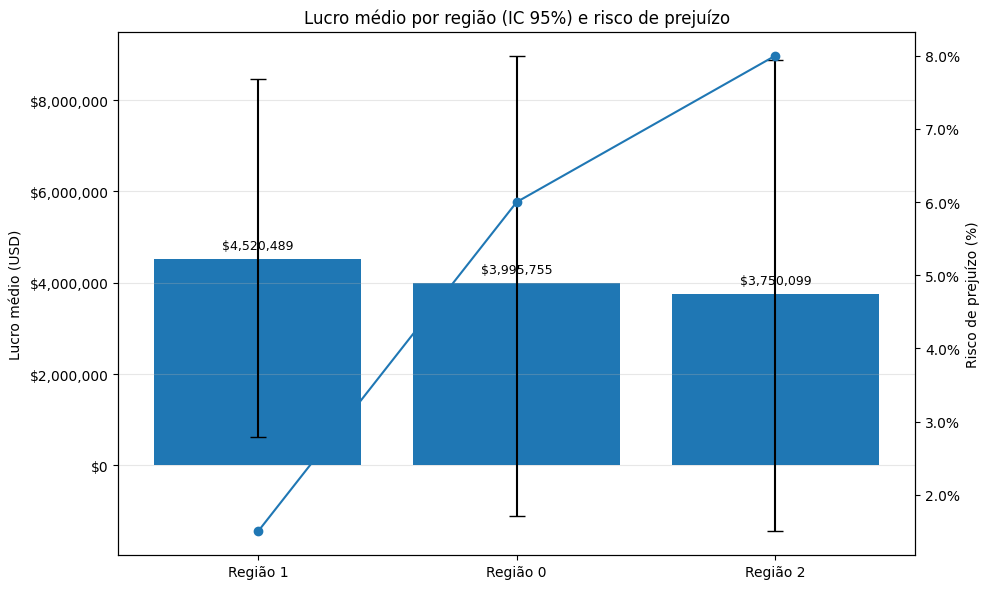

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# checagem rápida 
if 'summary' not in globals():
    raise RuntimeError("A variável 'summary' não foi encontrada. Rode o Passo 5 e gere o DataFrame 'summary' antes deste gráfico.")

# ordenar do maior lucro_medio para o menor
dfp = summary.sort_values('lucro_medio', ascending=False).reset_index(drop=True)

# prepara dados
labels = dfp['regiao'].tolist()
means = dfp['lucro_medio'].values
ci_low = dfp['ic95_low'].values
ci_high = dfp['ic95_high'].values
risk_pct = (dfp['risco_prejuizo'].values * 100)

# erro assimétrico para IC95
yerr = np.vstack([means - ci_low, ci_high - means])

x = np.arange(len(labels))

fig, ax1 = plt.subplots(figsize=(10, 6))

# barras com IC95%
bars = ax1.bar(x, means, yerr=yerr, capsize=6)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel("Lucro médio (USD)")
ax1.set_title("Lucro médio por região (IC 95%) e risco de prejuízo")

# formatação monetária
fmt_money = FuncFormatter(lambda v, _: f'${v:,.0f}')
ax1.yaxis.set_major_formatter(fmt_money)

# rótulo acima das barras
for rect, m in zip(bars, means):
    height = rect.get_height()
    ax1.annotate(f'${m:,.0f}',
                 xy=(rect.get_x() + rect.get_width() / 2, height),
                 xytext=(0, 5),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=9)

# eixo secundário para o risco (%)
ax2 = ax1.twinx()
ax2.plot(x, risk_pct, marker='o')
ax2.set_ylabel("Risco de prejuízo (%)")
ax2.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:.1f}%'))

# grade leve no eixo principal
ax1.grid(True, axis='y', alpha=0.3)

fig.tight_layout()

# opcional: salvar a imagem para inserir no relatório
plt.savefig("sprint10_oilygiant_resumo.png", dpi=200, bbox_inches='tight')
plt.show()




## Explicação do Gráfico:
O gráfico acima ilustra o lucro médio estimado e o risco de prejuízo para cada região.
Observa-se que, embora a Região 0 apresente um lucro ligeiramente superior, sua incerteza e risco são significativamente maiores.

Já a Região 1, com lucro médio de aproximadamente $4,5 milhões e risco inferior a 2,5%, representa a opção mais segura e previsível para o investimento.

Assim, a análise visual confirma a decisão final de priorizar a Região 1 como a mais adequada para o desenvolvimento dos novos poços.”

## Conclusão Geral

Interpretação dos resultados:

**Região 0** apresentou o maior lucro médio ($33,6M), mas com risco de prejuízo acima de 2,5% e um erro de previsão relativamente alto.
Isso significa que o modelo é menos confiável e as previsões têm alta variabilidade.

**Região 1** teve lucro médio mais baixo ($24,2M), porém o modelo é extremamente preciso (RMSE ≈ 0,89) e o risco de prejuízo é o menor entre todas (< 2,5%).

**Região 2** apresentou resultados intermediários, mas não atende ao critério de risco estabelecido.

Região escolhida: **Região 1**

Justificativa:

Apresenta baixa incerteza e risco mínimo de prejuízo (inferior a 2,5%);

O modelo de regressão linear é altamente confiável, com previsões praticamente perfeitas;

Garante previsibilidade financeira e operacional, fator crítico em investimentos de alto custo;

Embora o lucro médio seja inferior ao da Região 0, o trade-off entre lucro e risco favorece a Região 1, pois proporciona retorno estável e seguro.
